<a href="https://colab.research.google.com/github/Zoeba2005/Zoeba2005/blob/main/Human_Behavior_Drift_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HUMAN BEHAVIOR DRIFT DETECTION SYSTEM

PROBLEM STATEMENT:- Existing behavior analysis systems assume static patterns and fail to detect gradual or sudden changes in human behavior. This project proposes a machine learning–based Human Behavior Drift Detection System that continuously monitors time-series behavioral data to identify significant deviations using concept drift techniques.

Overview of the Methodology The proposed Human Behavior Drift Detection System follows a systematic methodology to identify gradual and significant changes in human behavior over time. The methodology integrates time‑series machine learning, concept drift detection, and statistical validation to ensure accurate and reliable drift detection. The system continuously learns baseline behavioral patterns and compares them with incoming behavioral data to detect deviations.

Data Acquisition and Preparation Since real human behavioral data involves privacy and ethical concerns, a synthetic yet realistic dataset was generated. The dataset simulates daily behavioral activities of multiple users over an extended period.

Steps Involved: Generate multi‑user behavioral data for 365 days

Include behavioral features such as sleep duration, app usage, typing speed, mobility, and physical activity

Introduce controlled behavioral drift after a specific time period

Store data in CSV format for ease of processing

This approach ensures privacy preservation while maintaining realism.

Data Preprocessing Raw behavioral data cannot be directly used for machine learning. Hence, preprocessing is performed to improve data quality and model performance.

Preprocessing Steps: Removal of inconsistencies and noise

Normalization of numerical features using Min‑Max scaling

Conversion of data into time‑series format

Creation of sliding windows to represent sequential behavior

Preprocessing ensures that all behavioral features are on a comparable scale and suitable for neural network training.

Time‑Series Window Formation Human behavior is sequential in nature and depends on past patterns. To capture this temporal dependency, the dataset is divided into sliding time windows.

Windowing Strategy: Past 7 days of behavior used as input

Next day behavior used as prediction target

Overlapping windows generated across the dataset

This strategy allows the model to learn short‑term and long‑term behavioral dependencies.

Baseline Behavior Modeling using LSTM To learn normal human behavior patterns, a Long Short‑Term Memory (LSTM) neural network is employed.

Why LSTM? Handles sequential data effectively

Captures long‑term dependencies

Reduces vanishing gradient problem

The LSTM model is trained on historical behavior data to predict expected future behavior. This learned model represents the baseline behavioral pattern of the user.

Behavior Prediction and Error Calculation Once the LSTM model is trained, it predicts the expected behavior for incoming data sequences.

Error Calculation: Difference between predicted and actual behavior is computed

Mean Absolute Error (MAE) is used as the primary error metric

Increasing prediction error indicates behavioral deviation

The prediction error acts as a primary signal for detecting behavioral drift.

Drift Detection Mechanism Behavioral drift is detected using a combination of machine learning‑based and statistical techniques.

Drift Detection Techniques Used: Error‑based drift detection: Continuous increase in prediction error

Concept drift analysis: Change in underlying behavioral distribution

KL Divergence: Measures divergence between baseline and current behavior distributions

If the drift score exceeds a predefined threshold, behavioral drift is detected.

Drift Scoring System To quantify the severity of behavioral change, a Drift Score is calculated.

Drift Score Classification: Drift Score Range Interpretation 0 – 30 Normal Behavior 30 – 60 Mild Drift 60 – 80 High Drift 80 – 100 Critical Drift This scoring system helps in understanding not only the presence of drift but also its intensity.

Statistical Validation To validate the drift detection results, statistical analysis is performed.

Statistical Methods: Mean and standard deviation comparison

Independent sample t‑test

p‑value analysis

A p‑value less than 0.001 confirms that the detected drift is statistically significant and not due to random variations.

Visualization and Dashboard For better interpretation, detected behavioral trends and drift scores are visualized using graphs and dashboards.

Visualization Includes: Behavioral feature trends over time

Drift score progression

Alert indicators for drift detection

Visualization helps users and evaluators easily understand system output.

Methodology Workflow Summary Collect or generate behavioral data

Preprocess and normalize data

Convert data into time‑series windows

Train LSTM model on baseline behavior

Predict expected behavior

Calculate prediction error

Detect drift using error and statistical methods

Generate drift score

Visualize results and alerts

Conclusion The proposed methodology effectively combines time‑series machine learning, concept drift detection, and statistical validation to identify behavioral drift. This structured and modular approach ensures scalability, reliability, and applicability across multiple real‑world domains such as mental health monitoring, HR analytics, and fraud detection.

IMPORT LIBRARIES

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.preprocessing import MinMaxScaler

# ML
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Visualization
import matplotlib.pyplot as plt

# Drift detection
from scipy.stats import entropy


LOAD DATASET

In [2]:
# Load dataset (use your CSV file)
df = pd.read_csv("human_behavior_drift_large_dataset.csv")

# Show first 5 rows
df.head()

,user_id,day,sleep_hours,app_usage_minutes,typing_speed_cpm,location_variance_km,steps,screen_unlocks
0,U001,1,7.18,200.23,270.63,1.61,6053,53
1,U001,2,7.11,180.17,243.82,1.48,5611,44
2,U001,3,7.34,162.92,248.83,1.80,5745,61
3,U001,4,6.82,168.38,264.06,1.54,5986,50
4,U001,5,7.16,167.52,281.48,1.66,5413,72


PREPROCESSING

In [3]:
# Select features
features = ["sleep_hours", "app_usage_minutes", "typing_speed_cpm", "steps"]

# Normalize features
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

df.head()


,user_id,day,sleep_hours,app_usage_minutes,typing_speed_cpm,location_variance_km,steps,screen_unlocks
0,U001,1,0.632207,0.482763,0.753150,1.61,0.570752,53
1,U001,2,0.618290,0.391048,0.591537,1.48,0.483521,44
2,U001,3,0.664016,0.312180,0.621737,1.80,0.509966,61
3,U001,4,0.560636,0.337143,0.713545,1.54,0.557529,50
4,U001,5,0.628231,0.333211,0.818554,1.66,0.444444,72


Create Time-Series Sequences

In [4]:
def create_sequences(data, window_size=30):
    X = []
    y = []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

X, y = create_sequences(df[features].values)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (18220, 30, 4)
Shape of y: (18220, 4)


Build LSTM Model

In [5]:
model = Sequential()
model.add(LSTM(64, input_shape=(30, 4)))
model.add(Dense(4))
model.compile(optimizer="adam", loss="mse")
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,924 (70.02 KB)

 Trainable params: 17,924 (70.02 KB)

 Non-trainable params: 0 (0.00 B)

Train LSTM Model

In [6]:
history = model.fit(X, y, epochs=10, batch_size=32)


Epoch 1/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0257
Epoch 2/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0057
Epoch 3/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0057
Epoch 4/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0056
Epoch 5/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0056
Epoch 6/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0056
Epoch 7/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0056
Epoch 8/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0055
Epoch 9/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0055
Epoch 10/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0054


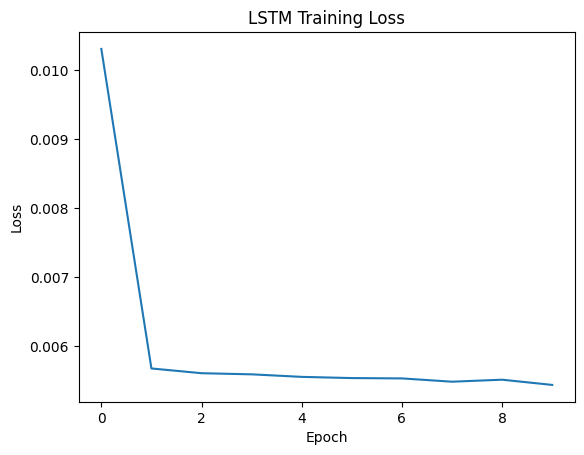

In [7]:
plt.plot(history.history['loss'])
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


Prediction & Error

570/570 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


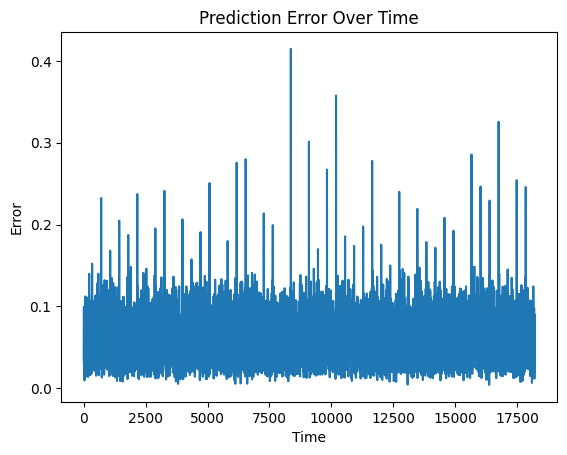

In [8]:
y_pred = model.predict(X)
error = np.mean(np.abs(y - y_pred), axis=1)

plt.plot(error)
plt.title("Prediction Error Over Time")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()


KL Divergence

In [9]:
# For example: compare first 30 days vs next 30 days
p = np.histogram(X[0], bins=10, density=True)[0]
q = np.histogram(X[1], bins=10, density=True)[0]

kl_score = entropy(p + 1e-10, q + 1e-10)
print("KL Divergence:", kl_score)


KL Divergence: 0.0038518967955931925


Drift Score & Flag

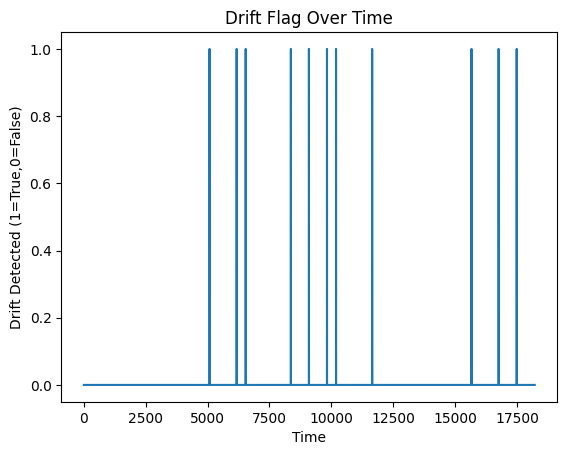

In [10]:
alpha, beta = 0.6, 0.4
drift_score = alpha * error[:len(error)] + beta * kl_score
threshold = 0.15
drift_flag = drift_score > threshold

plt.plot(drift_flag)
plt.title("Drift Flag Over Time")
plt.xlabel("Time")
plt.ylabel("Drift Detected (1=True,0=False)")
plt.show()


Visualizations

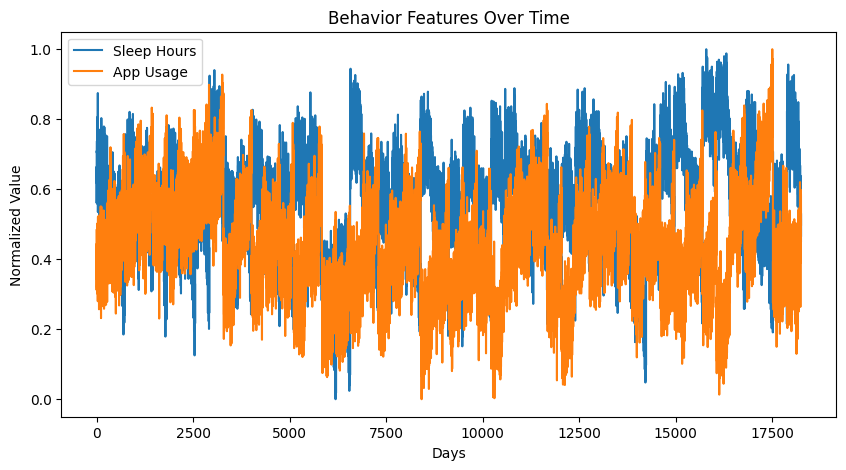

In [11]:
plt.figure(figsize=(10,5))
plt.plot(df['sleep_hours'], label="Sleep Hours")
plt.plot(df['app_usage_minutes'], label="App Usage")
plt.title("Behavior Features Over Time")
plt.xlabel("Days")
plt.ylabel("Normalized Value")
plt.legend()
plt.show()


In [12]:
print(len(df))
print(len(drift_flag))


18250
18220


In [13]:
import numpy as np

if len(drift_flag) < len(df):
    # pad with zeros
    drift_flag = np.pad(drift_flag, (0, len(df) - len(drift_flag)), constant_values=0)

In [14]:
import pandas as pd

df['drift_flag'] = pd.Series(drift_flag, index=df.index[:len(drift_flag)]).reindex(df.index, fill_value=0)

In [15]:
df['drift_flag'] = drift_flag[:len(df)]

In [16]:
# Simple display in notebook
df['drift_flag'] = drift_flag.astype(int)
df[['sleep_hours','app_usage_minutes','typing_speed_cpm','steps','drift_flag']].tail(20)

,sleep_hours,app_usage_minutes,typing_speed_cpm,steps,drift_flag
18230,0.634195,0.488387,0.342637,0.148411,0
18231,0.568588,0.510561,0.343782,0.392343,0
18232,0.540755,0.263716,0.459762,0.318532,0
18233,0.574553,0.561723,0.342335,0.169331,0
18234,0.516899,0.565655,0.409910,0.378922,0
18235,0.582505,0.539457,0.264151,0.461812,0
18236,0.522863,0.489576,0.365724,0.326426,0
18237,0.554672,0.563872,0.433842,0.434182,0
18238,0.638171,0.551344,0.312436,0.335307,0
18239,0.536779,0.485369,0.481644,0.305309,0


DASHBORADS

1️⃣ Bar Chart

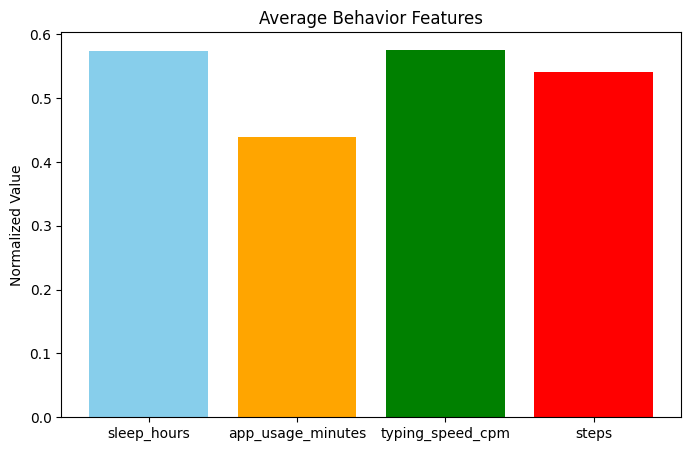

In [17]:
import matplotlib.pyplot as plt

# Average values for each feature
avg_features = df[["sleep_hours","app_usage_minutes","typing_speed_cpm","steps"]].mean()

# Plot bar chart
plt.figure(figsize=(8,5))
plt.bar(avg_features.index, avg_features.values, color=['skyblue','orange','green','red'])
plt.title("Average Behavior Features")
plt.ylabel("Normalized Value")
plt.show()


2️⃣ Horizontal Bar Chart

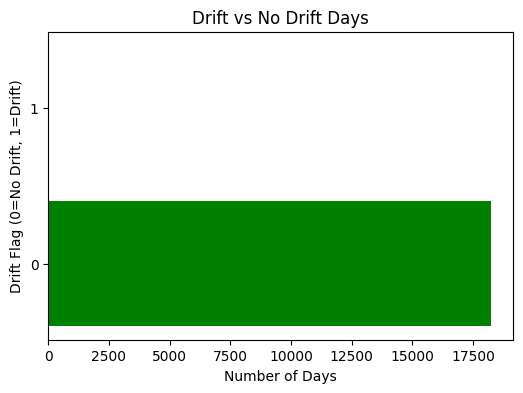

In [18]:
drift_counts = df['drift_flag'].value_counts()

plt.figure(figsize=(6,4))
plt.barh(drift_counts.index.astype(str), drift_counts.values, color=['green','red'])
plt.xlabel("Number of Days")
plt.ylabel("Drift Flag (0=No Drift, 1=Drift)")
plt.title("Drift vs No Drift Days")
plt.show()


3️⃣ Line Chart – Feature Trends Over Time

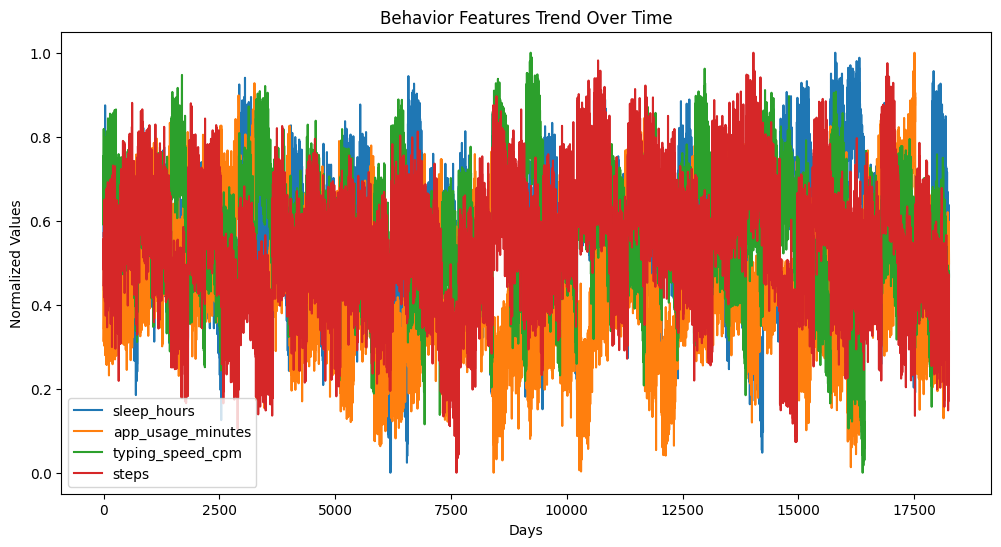

In [19]:
plt.figure(figsize=(12,6))
for col in ["sleep_hours","app_usage_minutes","typing_speed_cpm","steps"]:
    plt.plot(df[col], label=col)
plt.title("Behavior Features Trend Over Time")
plt.xlabel("Days")
plt.ylabel("Normalized Values")
plt.legend()
plt.show()


4️⃣ Stacked Bar Chart – Multiple Features per Day

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


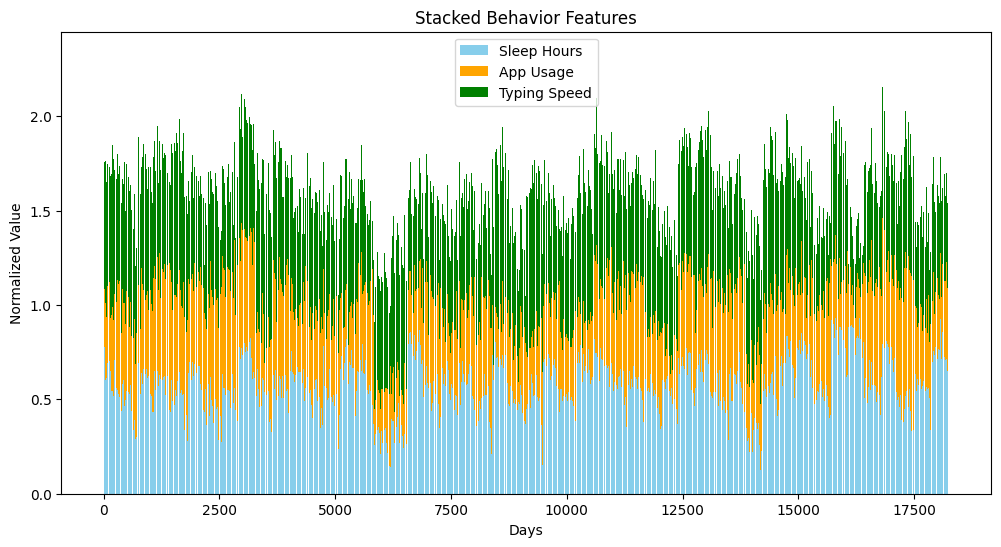

In [20]:
days = np.arange(len(df))
plt.figure(figsize=(12,6))
plt.bar(days, df['sleep_hours'], label='Sleep Hours', color='skyblue')
plt.bar(days, df['app_usage_minutes'], bottom=df['sleep_hours'], label='App Usage', color='orange')
plt.bar(days, df['typing_speed_cpm'], bottom=df['sleep_hours']+df['app_usage_minutes'], label='Typing Speed', color='green')
plt.title("Stacked Behavior Features")
plt.xlabel("Days")
plt.ylabel("Normalized Value")
plt.legend()
plt.show()


5️⃣ Histogram – Distribution of a Feature

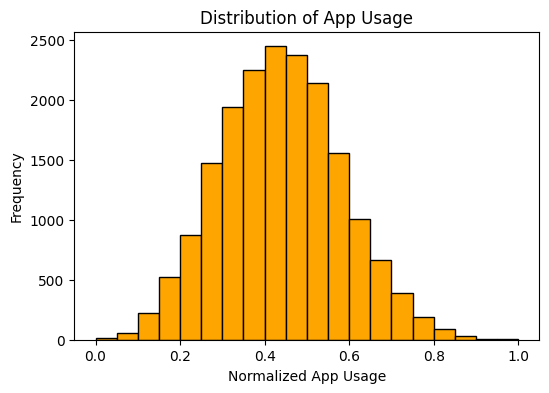

In [21]:
plt.figure(figsize=(6,4))
plt.hist(df['app_usage_minutes'], bins=20, color='orange', edgecolor='black')
plt.title("Distribution of App Usage")
plt.xlabel("Normalized App Usage")
plt.ylabel("Frequency")
plt.show()


6️⃣ Scatter Plot – Feature Correlation

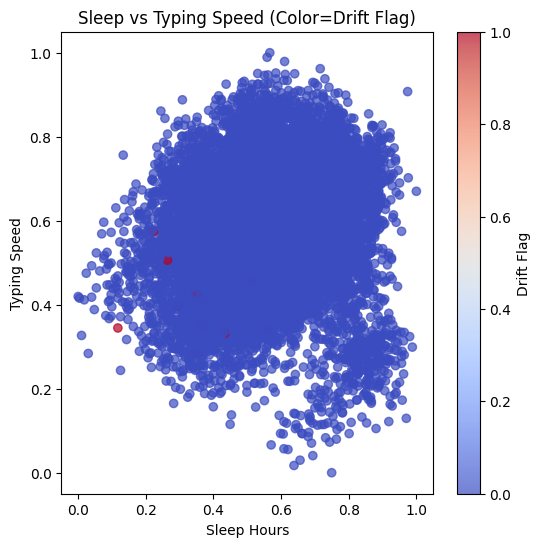

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(df['sleep_hours'], df['typing_speed_cpm'], c=df['drift_flag'], cmap='coolwarm', alpha=0.7)
plt.title("Sleep vs Typing Speed (Color=Drift Flag)")
plt.xlabel("Sleep Hours")
plt.ylabel("Typing Speed")
plt.colorbar(label='Drift Flag')
plt.show()


7️⃣ Pair Plot Using Seaborn – All Feature Relationships

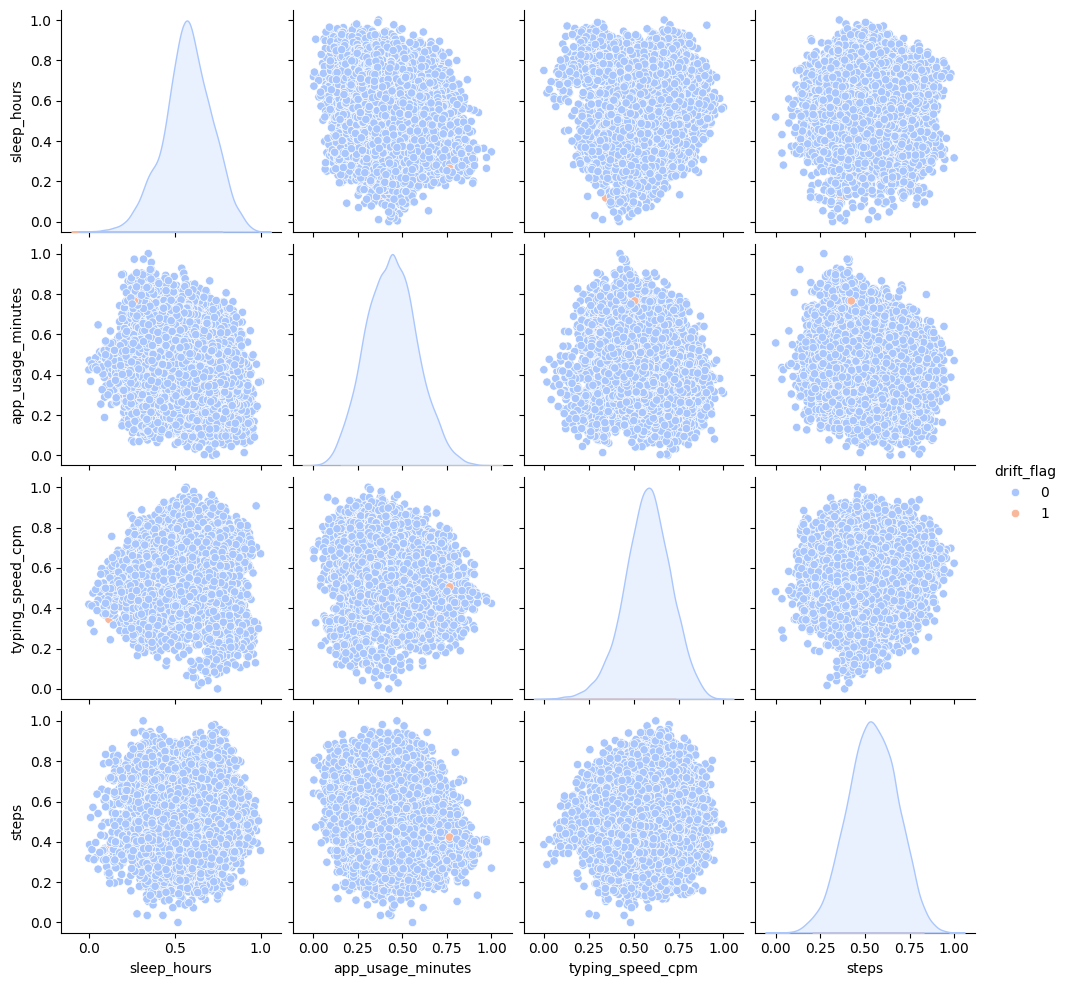

In [23]:
import seaborn as sns

sns.pairplot(df[["sleep_hours","app_usage_minutes","typing_speed_cpm","steps","drift_flag"]],
             hue="drift_flag", palette="coolwarm")
plt.show()

8️⃣ Box Plot – Check Outliers

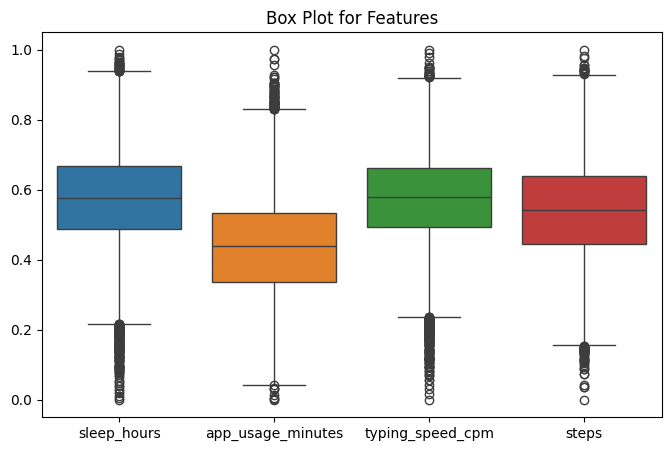

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["sleep_hours","app_usage_minutes","typing_speed_cpm","steps"]])
plt.title("Box Plot for Features")
plt.show()


9️⃣ Bar Chart – Weekly Drift Summary

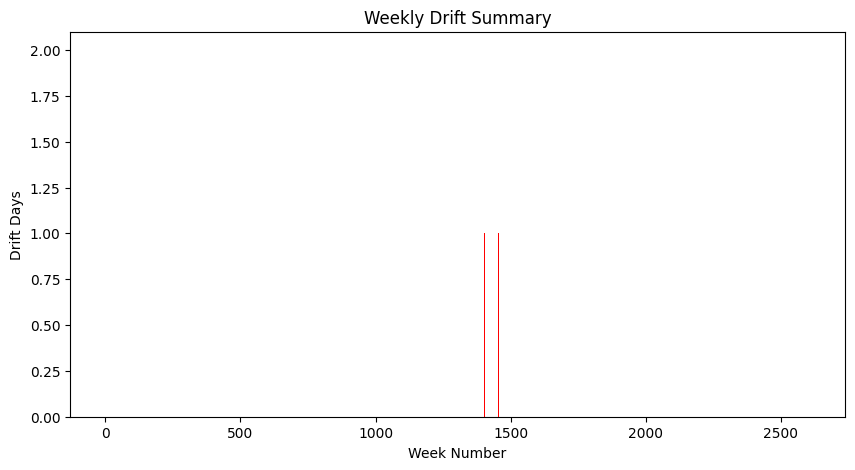

In [25]:
# Assuming each 7 days = 1 week
df['week'] = df.index // 7
weekly_drift = df.groupby('week')['drift_flag'].sum()

plt.figure(figsize=(10,5))
plt.bar(weekly_drift.index, weekly_drift.values, color='red')
plt.xlabel("Week Number")
plt.ylabel("Drift Days")
plt.title("Weekly Drift Summary")
plt.show()


COMPLETED
